In [3]:
import nifty.re as jft

import jax
import jax.numpy as jnp
import jax.random as random

import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
seed = 42
key = random.key(seed)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [4]:
s = jft.NormalPrior(mean = 0, std = 2, shape = (100)) # samples from distribution

Text(0, 0.5, 'Temperature Fluctuations')

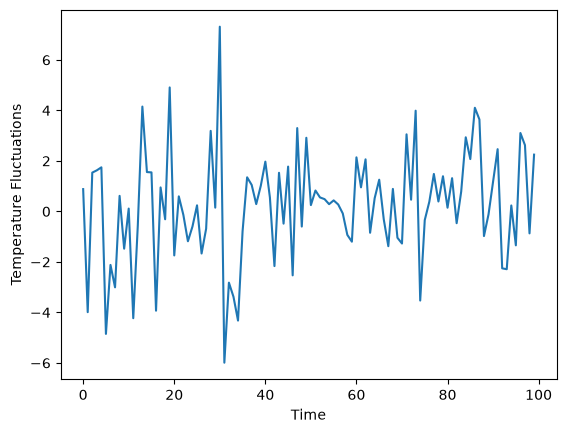

In [5]:
key, subkey = random.split(key)
latent_sample = jft.random_like(subkey, s.domain) # sample from prior
sample = s(latent_sample) # sample from distribution

plt.plot(sample)

plt.xlabel("Time")
plt.ylabel("Temperature Fluctuations")

In [6]:
dims = 100
distances = 0.01

In [7]:
grid  = jft.correlated_field.make_grid(dims, distances, harmonic_type = "fourier")

In [8]:
def amplitude_spectrum(k):
    return 2.5 / (k**2 + 5)

In [ ]:
k_lengths = grid.harmonic_grid.mode_lengths
amplitudes = amplitude_spectrum(k_lengths)
print("k_length: ", k_lengths)
print("amplitudes: ", amplitudes)

k_length:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]
amplitudes:  [0.5        0.41666667 0.27777778 0.17857143 0.11904762 0.08333333
 0.06097561 0.0462963  0.03623188 0.02906977 0.02380952 0.01984127
 0.01677852 0.01436782 0.01243781 0.01086957 0.00957854 0.0085034
 0.00759878 0.0068306  0.00617284 0.00560538 0.00511247 0.00468165
 0.00430293 0.00396825 0.00367107 0.00340599 0.00316857 0.00295508
 0.00276243 0.00258799 0.00242954 0.00228519 0.00215332 0.00203252
 0.0019216  0.00181951 0.00172533 0.00163827 0.00155763 0.0014828
 0.00141323 0.00134844 0.001288   0.00123153 0.00117869 0.00112918
 0.00108272 0.00103907 0.000998  ]


In [10]:
sqrt_harmonic_cov = amplitudes[grid.harmonic_grid.power_distributor]

In [13]:
class FixedPowerCorrelatedField(jft.Model):
    def __init__(self, sqrt_harmonic_cov, grid):
        self.sqrt_harmonic_cov = sqrt_harmonic_cov
        self.ht = jft.correlated_field.hartley
        self.harmonic_dvol = 1 / grid.total_volume

        super().__init__(
        domain=jax.ShapeDtypeStruct(shape=grid.shape, dtype=jnp.float64)
)
    def __call__(self, x):
        return self.harmonic_dvol * self.ht(self.sqrt_harmonic_cov * x)

s = FixedPowerCorrelatedField(sqrt_harmonic_cov, grid)

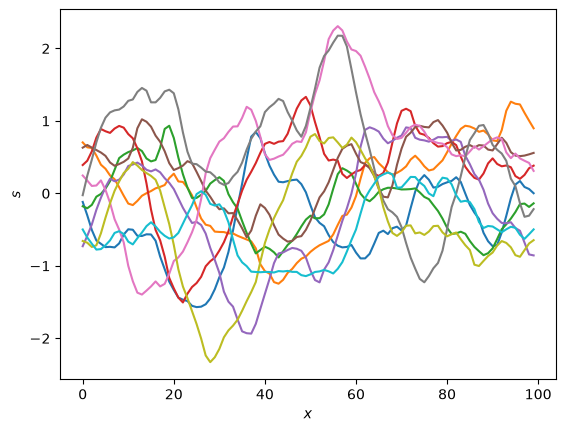

In [14]:
for i in range(10):
    key, subkey = random.split(key)
    latent_sample = jft.random_like(subkey, s.domain)
    sample = s(latent_sample)
    plt.plot(sample)
    plt.xlabel(r"$x$")
    plt.ylabel(r"$s$")
plt.show()